In [1]:
import sys
import os
import warnings

# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [2]:
# %load ../scripts/f_common_script.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import re
import scienceplots
from matplotlib.colors import TwoSlopeNorm
from crepes import WrapRegressor
from crepes.extras import margin, DifficultyEstimator, MondrianCategorizer
from mapie.regression import MapieQuantileRegressor
import lightgbm
from lightgbm import LGBMRegressor
import numpy as np
import scienceplots

# Section:Global variables
my_seed = 42
my_confidence = 0.9
confidences = [i / 100 for i in range(5, 100, 5)]
my_no_bins = 6
my_seed = 42
cap = 1.1
# set the seed of numpy
np.random.seed(my_seed)

# Load the data

In [3]:
from modules.utils import (
    get_values,
    calc_penalty,
    calculate_coverage,
    calculate_mean_size,
    calculate_median_size,
    calc_multi_level,
    calc_multi_level_WIS,
    calc_multi_level_cqr,
    calc_multi_level_cqr_WIS,
    calc_size_stratified_coverage,
    adaptive_mondrian_bins,
)

In [4]:
# Load the data
fname_aus_part1 = "../data/ausgrid/ausgrid_merged_preprocessed_part1.csv"
fname_aus_part2 = "../data/ausgrid/ausgrid_merged_preprocessed_part2.csv"
df_aus_part1 = pd.read_csv(fname_aus_part1)
df_aus_part2 = pd.read_csv(fname_aus_part2)

list_of_features = ["ghi_norm", "total_net_norm",
                    "air_temp_norm", "azimuth_norm"]
plt.style.use(["science"])
error_factor_part2 = np.load("../data/ausgrid/capacity_error_factor_part2.npy")

In [5]:
error_factor_part2

array(0.92438478)

In [6]:
# Filter data where ghi is greater than or equal to 0.01
df_aus_part1 = df_aus_part1[df_aus_part1["ghi"] >= 0.01]
df_aus_part2 = df_aus_part2[df_aus_part2["ghi"] >= 0.01]

In [7]:
# This is a problematic split.
# 2010-07-01 to 2011-07-01 from part1 as train
df_aus_train = df_aus_part1[
    (df_aus_part1["datetime"] >= "2012-07-01")
    & (df_aus_part1["datetime"] <= "2013-05-01")
]
# 2011-07-01 to 2012-07-01 06:00:00 from part2 as calibration
df_aus_cal = df_aus_part1[
    (df_aus_part1["datetime"] >= "2013-05-01")
    & (df_aus_part1["datetime"] <= "2013-07-01")
]
# 2018-12-23 to 2019-03-10 06:00:00 from part2 as test
df_aus_test = df_aus_part2[
    (df_aus_part2["datetime"] >= "2013-05-01")
    & (df_aus_part2["datetime"] <= "2013-07-01")
]

# Split data for CP

## Correct split by ghi

In [8]:
X_prop_train = df_aus_train[list_of_features]
X_cal = df_aus_cal[list_of_features]
X_test = df_aus_test[list_of_features]
y_prop_train = df_aus_train["total_pv_gen_normalized"]
y_cal = df_aus_cal["total_pv_gen_normalized"]
y_test = df_aus_test["total_pv_gen_normalized"]
X_train = np.concatenate([X_prop_train, X_cal], axis=0)
y_train = np.concatenate([y_prop_train, y_cal], axis=0)

In [9]:
X_prop_train.shape, X_cal.shape, X_test.shape

((7695, 4), (1259, 4), (1259, 4))

In [10]:
len_test = len(df_aus_test)
print(f"The length of the test set is {len_test}")

The length of the test set is 1259


In [11]:
# convert y_test to numpy array
y_test = np.array(y_test)
y_test = y_test * error_factor_part2

# Quantile Regression without MAPIE

# Quantile Regression

In [12]:
estimator = LGBMRegressor(
    random_state=my_seed,
    objective="quantile",
    alpha=1 - my_confidence,
    verbose=-1,
)
qreg90 = MapieQuantileRegressor(estimator=estimator)
qreg90.fit(X=X_prop_train, y=y_prop_train, random_state=my_seed)
qreg90_pred, qreg90_int = qreg90.predict(X_test)
# limit the prediction to 0 and 1
qreg90_pred = np.clip(qreg90_pred, 0, cap)
qreg90_int = np.clip(qreg90_int, 0, cap)
# add  the point predictions to df_aus_part2
df_aus_part2["qreg90_point_prediction"] = None
df_aus_part2.iloc[
    -len_test:, df_aus_part2.columns.get_loc("qreg90_point_prediction")
] = qreg90_pred
# add the prediction intervals to df_aus_part2
df_aus_part2["qreg90_lower"] = None
df_aus_part2["qreg90_upper"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("qreg90_lower")] = (
    qreg90_int[:, 0]
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("qreg90_upper")] = (
    qreg90_int[:, 1]
)

/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


# QRNN (Quantile Regression Neural Network)

Train a single network with output neurons for quantiles 5%, 10%, ..., 95% and evaluate multi-level sharpness, calibration error, interval score, and WIS.

In [13]:
from modules.qrnn import QRNN

# Train QRNN on same data as other methods (proper training + calibration)
qrnn = QRNN(random_state=my_seed, hidden_size=64,
            n_hidden_layers=2, epochs=150, batch_size=32, lr=1e-3)
qrnn.fit(X_train, y_train)
# Predict all quantiles: (n_test, 19) for levels 0.05, 0.10, ..., 0.95
qrnn_quantiles = qrnn.predict(X_test)
qrnn_quantiles = np.clip(qrnn_quantiles, 0, cap)
quantile_levels = qrnn.quantiles


def _quantile_idx(levels: np.ndarray, q: float) -> int:
    return int(np.argmin(np.abs(levels - q)))


# Point prediction (median) and 90% interval for dataframe
qrnn_point = qrnn.predict_median(X_test)
qrnn_point = np.clip(qrnn_point, 0, cap)
df_aus_part2["qrnn_point_prediction"] = None
df_aus_part2.iloc[-len_test:,
                  df_aus_part2.columns.get_loc("qrnn_point_prediction")] = qrnn_point
low_90, high_90 = _quantile_idx(
    quantile_levels, 0.05), _quantile_idx(quantile_levels, 0.95)
df_aus_part2["qrnn_lower"], df_aus_part2["qrnn_upper"] = None, None
df_aus_part2.iloc[-len_test:,
                  df_aus_part2.columns.get_loc("qrnn_lower")] = qrnn_quantiles[:, low_90]
df_aus_part2.iloc[-len_test:,
                  df_aus_part2.columns.get_loc("qrnn_upper")] = qrnn_quantiles[:, high_90]

# Multi-level evaluation: use central intervals (1-c)/2 and (1+c)/2
confidences_qrnn = [c for c in confidences if np.any(np.isclose(
    quantile_levels, (1 - c) / 2)) and np.any(np.isclose(quantile_levels, (1 + c) / 2))]
coverages_qrnn, mean_sizes_qrnn, penalties_qrnn = [], [], []
for confidence_i in confidences_qrnn:
    low_q = (1 - confidence_i) / 2
    high_q = (1 + confidence_i) / 2
    low_idx = _quantile_idx(quantile_levels, low_q)
    high_idx = _quantile_idx(quantile_levels, high_q)
    lower = qrnn_quantiles[:, low_idx]
    upper = qrnn_quantiles[:, high_idx]
    cp_int = np.stack([lower, upper], axis=1)
    coverages_qrnn.append(calculate_coverage(y_test, cp_int))
    mean_sizes_qrnn.append(calculate_mean_size(cp_int))
    penalties_qrnn.append(calc_penalty(y_test, lower, upper, confidence_i))

qrnn_sharpness = np.mean(mean_sizes_qrnn)
qrnn_calibration_error = np.mean(penalties_qrnn)
qrnn_interval_score = qrnn_sharpness + qrnn_calibration_error

# WIS: median = 0.5 quantile
med_idx = _quantile_idx(quantile_levels, 0.5)
qrnn_median = qrnn_quantiles[:, med_idx]
K = len(confidences_qrnn)
w0 = 1 / 2
wk_scores = np.zeros((len(y_test), K))
for idx, confidence_i in enumerate(confidences_qrnn):
    low_q = (1 - confidence_i) / 2
    high_q = (1 + confidence_i) / 2
    low_idx = _quantile_idx(quantile_levels, low_q)
    high_idx = _quantile_idx(quantile_levels, high_q)
    lower = qrnn_quantiles[:, low_idx]
    upper = qrnn_quantiles[:, high_idx]
    width = upper - lower
    alpha_i = 1 - confidence_i
    penalties = np.zeros_like(y_test)
    penalties[y_test < lower] = 2 * \
        (lower[y_test < lower] - y_test[y_test < lower]) / alpha_i
    penalties[y_test > upper] = 2 * \
        (y_test[y_test > upper] - upper[y_test > upper]) / alpha_i
    wk_scores[:, idx] = (alpha_i / 2) * (width + penalties)
qrnn_WIS = np.mean((1 / (K + 1 / 2)) * (w0 * np.abs(y_test -
                   qrnn_median) + np.sum(wk_scores, axis=1)))

print(f"The sharpness of QRNN is {qrnn_sharpness}")
print(f"The calibration error of QRNN is {qrnn_calibration_error}")
print(f"The interval score of QRNN is {qrnn_interval_score}")
print(f"The WIS of QRNN is {qrnn_WIS}")

The sharpness of QRNN is 0.06222625449299812
The calibration error of QRNN is 0.10734237983821004
The interval score of QRNN is 0.16956863433120817
The WIS of QRNN is 0.03657434363155449


## Visualize the result

## Different levels of confidence


In [14]:
# generate a list of confidence from 5 to 95 with step 5
warnings.filterwarnings('ignore')
qreg_sharpness, qreg_calibration_error, qreg_interval_score = calc_multi_level_cqr(
    X_test=X_test,
    y_test=y_test,
    confidences=confidences,
    X_prop_train=X_prop_train,
    y_prop_train=y_prop_train,
    X_cal=X_cal,
    y_cal=y_cal,
    cap=cap,
    calibrate=False,
)

In [15]:
warnings.filterwarnings('ignore')
qreg_WIS = calc_multi_level_cqr_WIS(
    X_test=X_test,
    y_test=y_test,
    confidences=confidences,
    X_prop_train=X_prop_train,
    y_prop_train=y_prop_train,
    X_cal=X_cal,
    y_cal=y_cal,
    cap=cap,
    calibrate=False,
)

In [16]:
print(f"The sharpness of QREG is {qreg_sharpness}")
print(f"The calibration error of QREG is {qreg_calibration_error}")
print(f"The interval score of QREG is {qreg_interval_score}")
print(f"The WIS of QREG is {qreg_WIS}")

The sharpness of QREG is 0.0662721634139402
The calibration error of QREG is 0.1172730020160038
The interval score of QREG is 0.18354516542994398
The WIS of QREG is 0.03823595577009822


# CQR

In [17]:
cqr_reg = MapieQuantileRegressor(estimator=estimator)
cqr_reg.fit(
    X=X_prop_train, y=y_prop_train, X_calib=X_cal, y_calib=y_cal, random_state=my_seed
)
cqr_pred, cqr_int = cqr_reg.predict(X_test)
# limit the prediction to 0 and 1
cqr_pred = np.clip(cqr_pred, 0, cap)
cqr_int = np.clip(cqr_int, 0, cap)

In [18]:
# add  the point predictions to df_aus_part2
df_aus_part2["cqr_point_prediction"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cqr_point_prediction")] = (
    cqr_pred
)
# add the prediction intervals to df_aus_part2
df_aus_part2["cqr_lower"] = None
df_aus_part2["cqr_upper"] = None
df_aus_part2.iloc[-len_test:,
                  df_aus_part2.columns.get_loc("cqr_lower")] = cqr_int[:, 0]
df_aus_part2.iloc[-len_test:,
                  df_aus_part2.columns.get_loc("cqr_upper")] = cqr_int[:, 1]

## Different levels of confidence

In [19]:
# generate a list of confidence from 5 to 95 with step 5
warnings.filterwarnings('ignore')
cqr_sharpness, cqr_calibration_error, cqr_interval_score = calc_multi_level_cqr(
    X_test, y_test, confidences, X_prop_train, y_prop_train, X_cal, y_cal, cap=cap
)

In [20]:
warnings.filterwarnings('ignore')
cqr_WIS = calc_multi_level_cqr_WIS(
    X_test, y_test, confidences, X_prop_train, y_prop_train, X_cal, y_cal, cap=cap
)

In [21]:
print(f"The sharpness of CQR is {cqr_sharpness}")
print(f"The calibration error of CQR is {cqr_calibration_error}")
print(f"The interval score of CQR is {cqr_interval_score}")
print(f"The WIS of CQR is {cqr_WIS}")

The sharpness of CQR is 0.07846730119735994
The calibration error of CQR is 0.09808330368447139
The interval score of CQR is 0.17655060488183133
The WIS of CQR is 0.03740179810754983


# Standard CP

In [22]:
lgb = WrapRegressor(
    LGBMRegressor(n_jobs=-1,
                  random_state=my_seed, verbose=-1)
)
lgb.fit(X_prop_train, y_prop_train)

In [23]:
lgb.calibrate(X_cal, y_cal, seed=my_seed)
display(lgb)

WrapRegressor(learner=LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), calibrated=True, predictor=ConformalRegressor(fitted=True, normalized=False, mondrian=False))

In [24]:
# add the predictions to the dataframe
df_aus_part2["lgbr_point_prediction"] = lgb.predict(
    df_aus_part2[list_of_features])

In [25]:
# check the r2 score
standard_cp_r2 = r2_score(
    df_aus_part2["total_pv_gen_normalized"], df_aus_part2["lgbr_point_prediction"]
)
print(standard_cp_r2)

0.9484399253531136


In [26]:
standard_cp90_int = lgb.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
standard_cp90_lower = standard_cp90_int[:, 0]
standard_cp90_upper = standard_cp90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["standard_cp90_upper"] = None
df_aus_part2["standard_cp90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("standard_cp90_lower")] = (
    standard_cp90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("standard_cp90_upper")] = (
    standard_cp90_upper
)

In [27]:
# Accessing the wrapped learner
learner_prop = lgb.learner

## Different Confidences

In [28]:
# use a list to store the coverages, mean sizes, and median sizes
coverages_standard = []
mean_sizes_standard = []
penalties_standard = []
# use a for loop to calculate the coverage, mean size, and median size for each confidence
for confidence_i in confidences:
    standard_int = lgb.predict_int(
        X_test, y_min=0, y_max=cap, confidence=confidence_i, seed=my_seed
    )
    standard_lower = standard_int[:, 0]
    standard_upper = standard_int[:, 1]
    coverages_standard.append(calculate_coverage(y_test, standard_int))
    mean_sizes_standard.append(calculate_mean_size(standard_int))
    penalties_standard.append(
        calc_penalty(y_test, standard_lower, standard_upper, confidence_i)
    )

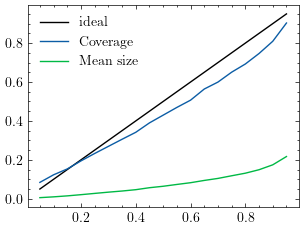

In [29]:
# plot the coverage and mean size
plt.plot(confidences, confidences, "k-", label="ideal")
plt.plot(confidences, coverages_standard, label="Coverage")
plt.plot(confidences, mean_sizes_standard, label="Mean size")
plt.legend()
plt.show()

In [30]:
# calculate Sharpness, Average interval width (IW)
sharpness_standard = np.mean(mean_sizes_standard)
print(f"The sharpness of standard CP is {sharpness_standard}")
# calculate the calibration error
calibration_error_standard = np.mean(penalties_standard)
print(f"The calibration error of standard CP is {calibration_error_standard}")
# calculate interval score
interval_score_standard = sharpness_standard + calibration_error_standard
print(f"The interval score of standard CP is {interval_score_standard}")

The sharpness of standard CP is 0.07713870792582755
The calibration error of standard CP is 0.11145524165627793
The interval score of standard CP is 0.18859394958210549


In [31]:
print(calc_multi_level(lgb, X_test, y_test))

(np.float64(0.07713870792582755), np.float64(0.11145524165627793), np.float64(0.18859394958210549))


# CP with diffifculty Esimator

# CP with Mondrian Binning

## Without difficulty estimator

In [32]:
mc = MondrianCategorizer()
# mc.fit(X=X_prop_train, f=get_values, no_bins=my_no_bins)
mc.fit(X=X_cal, f=get_values, no_bins=my_no_bins)
lgb_mond = WrapRegressor(learner_prop)
lgb_mond.calibrate(X_cal, y_cal, mc=mc, seed=my_seed)
mond_cp90_int = lgb_mond.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
mond_cp90_lower = mond_cp90_int[:, 0]
mond_cp90_upper = mond_cp90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["mond_cp90_upper"] = None
df_aus_part2["mond_cp90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("mond_cp90_lower")] = (
    mond_cp90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("mond_cp90_upper")] = (
    mond_cp90_upper
)

In [33]:
prob_method = "cp_amb"
learner_cp_amb = WrapRegressor(learner_prop)
optimal_no_bins = adaptive_mondrian_bins(
    learner_cp_amb, X_cal, y_cal, my_seed, prob_method)
print(f"The optimal number of bins is {optimal_no_bins}")
lgb_cp_amb = WrapRegressor(learner_prop)
mc_cp_amb = MondrianCategorizer()
mc_cp_amb.fit(X=X_cal, f=get_values, no_bins=optimal_no_bins)
lgb_cp_amb.calibrate(X_cal, y_cal, cps=False, mc=mc_cp_amb, seed=my_seed)
cp_amb90_int = lgb_cp_amb.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
cp_amb90_lower = cp_amb90_int[:, 0]
cp_amb90_upper = cp_amb90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["cp_amb90_upper"] = None
df_aus_part2["cp_amb90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cp_amb90_lower")] = (
    cp_amb90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cp_amb90_upper")] = (
    cp_amb90_upper
)

The optimal number of bins is 60


## Find the best no_bins for Mondrian Binning

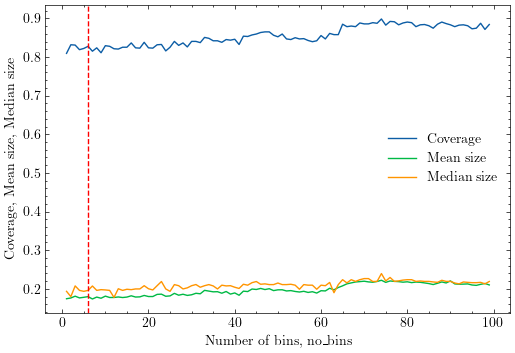

The coverage of no_bins=1 is 0.8093725178713265
The coverage of no_bins=2 is 0.8316123907863384
The coverage of no_bins=3 is 0.8308181096108023
The coverage of no_bins=4 is 0.8189038919777601
The coverage of no_bins=5 is 0.8220810166799047
The coverage of no_bins=6 is 0.8276409849086577
The coverage of no_bins=7 is 0.8149324861000794
The coverage of no_bins=8 is 0.8236695790309769
The coverage of no_bins=9 is 0.8109610802223988
The coverage of no_bins=10 is 0.82922954725973
The coverage of no_bins=11 is 0.8276409849086577
The coverage of no_bins=12 is 0.8212867355043686
The coverage of no_bins=13 is 0.8204924543288324
The coverage of no_bins=14 is 0.8252581413820492
The coverage of no_bins=15 is 0.8252581413820492
The coverage of no_bins=16 is 0.8363780778395552
The coverage of no_bins=17 is 0.8236695790309769
The coverage of no_bins=18 is 0.8228752978554408
The coverage of no_bins=19 is 0.8379666401906275
The coverage of no_bins=20 is 0.8236695790309769
The coverage of no_bins=21 is 0

In [34]:
def find_best_no_bins_mond():
    # use a for loop to find the best k
    coverages_mond = []
    mean_sizes_mond = []
    median_sizes_mond = []
    for no_bins in range(1, 100):
        mc = MondrianCategorizer()
        mc.fit(X=X_cal, f=get_values, no_bins=no_bins)
        lgb_mond = WrapRegressor(learner_prop)
        lgb_mond.calibrate(X_cal, y_cal, mc=mc, seed=my_seed)
        mond_cp90_int = lgb_mond.predict_int(
            X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
        )
        coverages_mond.append(calculate_coverage(y_test, mond_cp90_int))
        mean_sizes_mond.append(calculate_mean_size(mond_cp90_int))
        median_sizes_mond.append(calculate_median_size(mond_cp90_int))
    # plot the coverages, mean sizes, and median sizes
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 100), coverages_mond, label="Coverage")
    plt.plot(range(1, 100), mean_sizes_mond, label="Mean size")
    plt.plot(range(1, 100), median_sizes_mond, label="Median size")
    # add a title
    plt.xlabel("Number of bins, no_bins")
    plt.ylabel("Coverage, Mean size, Median size")
    # add a line where x=12
    plt.axvline(x=6, color="red", linestyle="--")
    plt.legend()
    plt.savefig("../figs/best_no_bins_mond_part12.pdf", format="pdf")
    plt.show()
    # save the figure

    # print the coverages and its corresponding index
    for i in range(len(coverages_mond)):
        print(f"The coverage of no_bins={i + 1} is {coverages_mond[i]}")


find_best_no_bins_mond()

# CPS

## Standard CPS

In [35]:
lgb_cps = WrapRegressor(learner_prop)
lgb_cps.calibrate(X_cal, y_cal, cps=True, seed=my_seed)
display(lgb_cps)

WrapRegressor(learner=LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), calibrated=True, predictor=ConformalPredictiveSystem(fitted=True, normalized=False, mondrian=False))

In [36]:
cps_cp90_int = lgb_cps.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
cps_cp90_lower = cps_cp90_int[:, 0]
cps_cp90_upper = cps_cp90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["cps_cp90_upper"] = None
df_aus_part2["cps_cp90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_cp90_lower")] = (
    cps_cp90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_cp90_upper")] = (
    cps_cp90_upper
)

## CPS with mondrian binning

In [37]:
lgb_cps_mond = WrapRegressor(learner_prop)
lgb_cps_mond.calibrate(X_cal, y_cal, cps=True, mc=mc, seed=my_seed)
display(lgb_cps_mond)
cps_mond_cp90_int = lgb_cps_mond.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
cps_mond_cp90_lower = cps_mond_cp90_int[:, 0]
cps_mond_cp90_upper = cps_mond_cp90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["cps_mond_cp90_upper"] = None
df_aus_part2["cps_mond_cp90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_mond_cp90_lower")] = (
    cps_mond_cp90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_mond_cp90_upper")] = (
    cps_mond_cp90_upper
)

WrapRegressor(learner=LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), calibrated=True, predictor=ConformalPredictiveSystem(fitted=True, normalized=False, mondrian=True))

In [38]:
warnings.filterwarnings('ignore')
prob_method = "cps_amb"
learner_cps_amb = WrapRegressor(learner_prop)
optimal_no_bins = adaptive_mondrian_bins(
    learner_cps_amb, X_cal, y_cal, my_seed, prob_method)
print(f"The optimal number of bins is {optimal_no_bins}")
lgb_cps_amb = WrapRegressor(learner_prop)
mc_cps_amb = MondrianCategorizer()
mc_cps_amb.fit(X=X_cal, f=get_values, no_bins=optimal_no_bins)
lgb_cps_amb.calibrate(X_cal, y_cal, cps=True, mc=mc_cps_amb, seed=my_seed)
cps_amb90_int = lgb_cps_amb.predict_int(
    X_test, y_min=0, y_max=cap, confidence=my_confidence, seed=my_seed
)
cps_amb90_lower = cps_amb90_int[:, 0]
cps_amb90_upper = cps_amb90_int[:, 1]
# add the probabilities to the dataframe
df_aus_part2["cps_amb90_upper"] = None
df_aus_part2["cps_amb90_lower"] = None
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_amb90_lower")] = (
    cps_amb90_lower
)
df_aus_part2.iloc[-len_test:, df_aus_part2.columns.get_loc("cps_amb90_upper")] = (
    cps_amb90_upper
)

The optimal number of bins is 24


# Investigating the prediction intervals

In [39]:
coverages = []
mean_sizes = []
median_sizes = []
size_stratified_coverages = []

prediction_intervals = {
    "qreg90": qreg90_int,
    "cqr90": cqr_int,
    "qrnn90": np.column_stack([
        df_aus_part2["qrnn_lower"].iloc[-len_test:].values,
        df_aus_part2["qrnn_upper"].iloc[-len_test:].values,
    ]),
    "std": standard_cp90_int,
    "mond": mond_cp90_int,
    "cps": cps_cp90_int,
    "cps_mond": cps_mond_cp90_int,
    "cp_amb": cp_amb90_int,
    "cps_amb": cps_amb90_int,
}

In [40]:
# convert y_test to numpy array
y_test = np.array(y_test)
for name in prediction_intervals.keys():
    intervals = prediction_intervals[name]
    # calculate the coverage
    coverages.append(calculate_coverage(y_test, intervals))
    # calculate the mean size
    mean_sizes.append(calculate_mean_size(intervals))
    # calculate the median size
    median_sizes.append(calculate_median_size(intervals))
    # calculate the size stratified coverage
    size_stratified_coverages.append(
        calc_size_stratified_coverage(intervals, y_test))
pred_int_df = pd.DataFrame(
    {
        "Coverage": coverages,
        "SSC": size_stratified_coverages,
        "Mean size": mean_sizes,
        "Median size": median_sizes,
    },
    index=list(prediction_intervals.keys()),
)

pred_int_df.loc["Mean"] = [
    pred_int_df["Coverage"].mean(),
    pred_int_df["SSC"].mean(),
    pred_int_df["Mean size"].mean(),
    pred_int_df["Median size"].mean(),
]
display(pred_int_df.round(4))

,Coverage,SSC,Mean size,Median size
qreg90,0.7705,0.7255,0.1482,0.1538
cqr90,0.8435,0.7924,0.1763,0.1870
qrnn90,0.7736,0.7017,0.1433,0.1435
std,0.8094,0.7757,0.1744,0.1936
mond,0.8237,0.7924,0.1788,0.1894
cps,0.8197,0.7857,0.1536,0.1759
cps_mond,0.8292,0.8071,0.1622,0.1726
cp_amb,0.8554,0.8162,0.1955,0.2110
cps_amb,0.8753,0.8520,0.1917,0.2041
Mean,0.8223,0.7832,0.1694,0.1812


# Multi-level

In [41]:
# calculate sharpness, calibration error, and interval score for each method
# create a list of learners
learners = [lgb, lgb_mond, lgb_cps, lgb_cps_mond, lgb_cp_amb, lgb_cps_amb]
# create a dataframe to store the results
results_df = pd.DataFrame(
    {"Sharpness": [], "Calibration error": [], "Interval score": [], "WIS": []},
    index=[],
)
for learner in learners:
    sharpness, calibration_error, interval_score = calc_multi_level(
        learner, X_test, y_test
    )
    w_IS = calc_multi_level_WIS(learner, X_test, y_test)
    # add the results to the dataframe as a new row, the index is the name of the learner
    obj_name = [name for name, value in locals().items()
                if value is learner][0]
    results_df.loc[obj_name] = [sharpness,
                                calibration_error, interval_score, w_IS]
# QRNN (precomputed in QRNN section)
results_df.loc["qrnn"] = [
    qrnn_sharpness,
    qrnn_calibration_error,
    qrnn_interval_score,
    qrnn_WIS,
]
display(results_df)

,Sharpness,Calibration error,Interval score,WIS
lgb,0.077139,0.111455,0.188594,0.039759
lgb_mond,0.082133,0.099582,0.181715,0.038687
lgb_cps,0.066449,0.098076,0.164526,0.034415
lgb_cps_mond,0.070556,0.088807,0.159363,0.033200
lgb_cp_amb,0.089437,0.094356,0.183793,0.038799
lgb_cps_amb,0.076584,0.082998,0.159581,0.033352
qrnn,0.062226,0.107342,0.169569,0.036574


# Does CP work as expected? 

In [42]:
# use 8 lists to store the 8 lists of coverages
coverages_by_learner = {
    learner_name: []
    for learner_name in [
        "lgb",
        "lgb_mond",
        "lgb_cps",
        "lgb_cps_mond",
    ]
}
mean_sizes_by_learner = {
    learner_name: [] for learner_name in ["lgb", "lgb_mond", "lgb_cps", "lgb_cps_mond"]
}
median_sizes_by_learner = {
    learner_name: []
    for learner_name in [
        "lgb",
        "lgb_mond",
        "lgb_cps",
        "lgb_cps_mond",
    ]
}
penalties_by_learner = {
    learner_name: []
    for learner_name in [
        "lgb",
        "lgb_mond",
        "lgb_cps",
        "lgb_cps_mond",
    ]
}

# Create mapping of learner names to M1-M8 labels
method_labels = {
    "lgb": "M1",
    "lgb_mond": "M3",
    "lgb_cps": "M5",
    "lgb_cps_mond": "M7",
}

# Calculate metrics for each confidence level and learner
for confidence_i in confidences:
    for learner, learner_name in zip(learners, coverages_by_learner.keys()):
        int_i = learner.predict_int(
            X_test, y_min=0, y_max=cap, confidence=confidence_i, seed=my_seed
        )
        int_lower = int_i[:, 0]
        int_upper = int_i[:, 1]

        coverages_by_learner[learner_name].append(
            calculate_coverage(y_test, int_i))
        mean_sizes_by_learner[learner_name].append(calculate_mean_size(int_i))
        median_sizes_by_learner[learner_name].append(
            calculate_median_size(int_i))
        penalties_by_learner[learner_name].append(
            calc_penalty(y_test, int_lower, int_upper, confidence_i)
        )

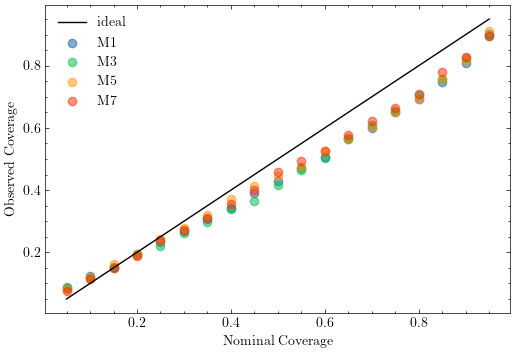

In [43]:
# plot the coverages
# plot a solid line where x=y
fig = plt.figure(figsize=(6, 4))
plt.plot(confidences, confidences, "k-", label="ideal")
# plot the coverages for each learner
for learner_name in coverages_by_learner.keys():
    plt.scatter(
        confidences,
        coverages_by_learner[learner_name],
        alpha=0.5,
        label=method_labels[learner_name],
    )
plt.xlabel("Nominal Coverage")
plt.ylabel("Observed Coverage")
plt.legend()
plt.savefig("../figs/coverages_part12.pdf", format="pdf")
plt.show()

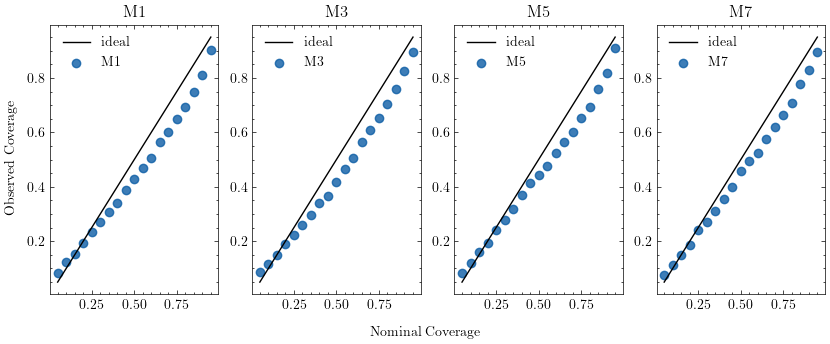

In [44]:
# Create figure with 4x2 subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 3.5))
axes = axes.flatten()  # Flatten to make iteration easier

# Plot for each method
for idx, (learner_name, method_label) in enumerate(method_labels.items()):
    # Plot on corresponding subplot
    ax = axes[idx]

    # Plot ideal line
    ax.plot(confidences, confidences, "k-", label="ideal")

    # Plot actual coverage
    ax.scatter(
        confidences, coverages_by_learner[learner_name], alpha=0.8, label=method_label
    )

    # Add title only
    ax.set_title(f"{method_label}")
    ax.legend()

    # Remove individual x and y labels
    if idx < 6:  # Remove x labels for all but bottom row
        ax.set_xlabel("")
    if idx % 2 != 0:  # Remove y labels for right column
        ax.set_ylabel("")

# Add common x and y labels
fig.text(0.5, 0.00, "Nominal Coverage", ha="center", va="center")
fig.text(0.08, 0.5, "Observed Coverage", va="center", rotation="vertical")

# Adjust layout to prevent overlap
# plt.tight_layout()
# save the figure
fig.savefig("../figs/coverage_comparison1.pdf", format="pdf")
plt.show()